Processing JSON Sounding: RAP_1778695200_405-8022.json
Lapse rate =  9.44174930202604
Skew-T Plot saved successfully as RAP_JSON_SkewT_Plot.png
Theta-E Profile saved successfully as RAP_JSON_ThetaE_Plot.png


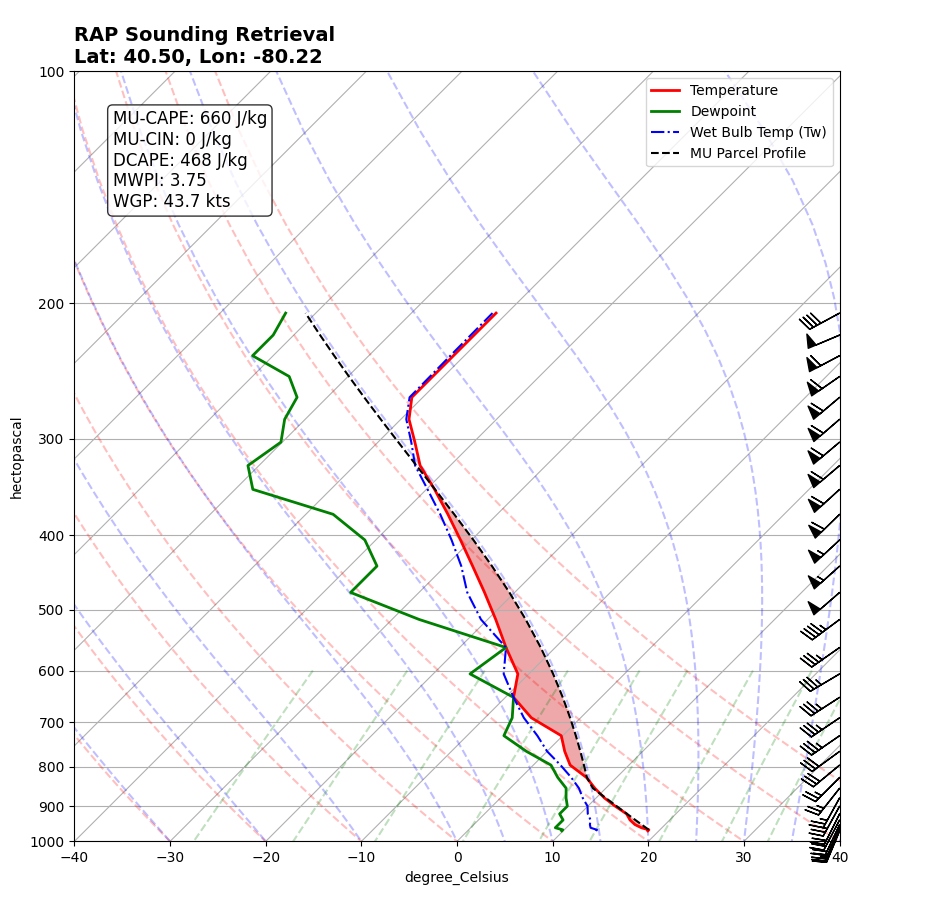

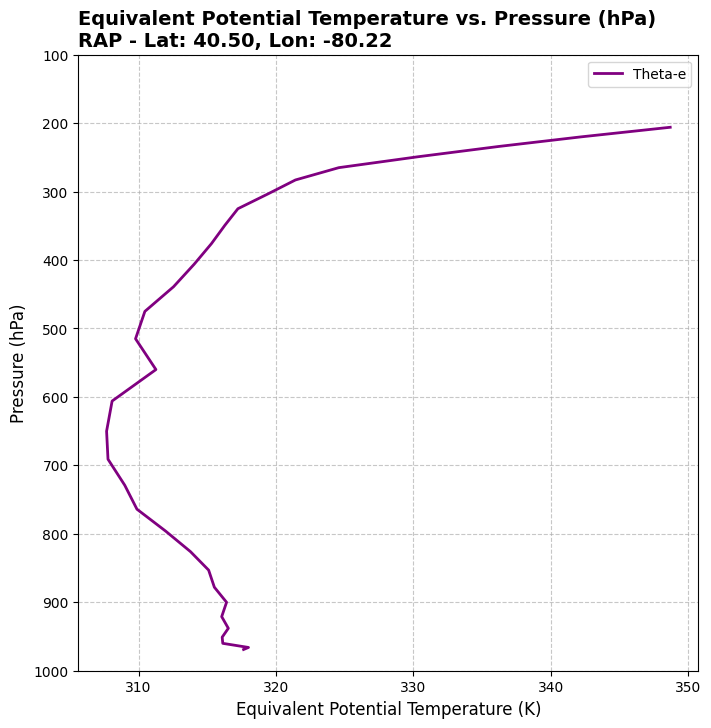

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units

def get_standard_height_km(pressure_hpa):
    """
    Interpolates geometric height (km) for a given pressure array 
    based on the 1976 US Standard Atmosphere Table.
    """
    # Standard Atmosphere Table (Z in km, P in hPa)
    std_z = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22, 24, 26, 28, 30])
    std_p = np.array([1013.25, 898.76, 795.01, 701.21, 616.60, 540.48, 472.17, 411.05, 356.51, 308.00, 264.99, 
                      227.00, 193.99, 165.79, 141.70, 121.11, 103.52, 88.49, 75.65, 64.67, 55.29, 40.47, 29.71, 
                      21.88, 16.16, 11.97])
    
    # np.interp expects x-coordinates to be monotonically increasing.
    # We use the natural log of pressure and reverse the arrays.
    log_p = np.log(std_p[::-1])
    z_rev = std_z[::-1]
    
    log_target_p = np.log(pressure_hpa)
    height_km = np.interp(log_target_p, log_p, z_rev)
    return height_km

def calculate_dcape(p, T, Td):
    """Calculates DCAPE (Downdraft CAPE) by finding min Theta-e."""
    try:
        theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)
        
        sfc_p = p[0]
        search_layer_mask = p >= (sfc_p - 400 * units.hPa)
        min_thetae_idx = np.argmin(theta_e[search_layer_mask])
        
        p_origin = p[search_layer_mask][min_thetae_idx]
        T_origin = T[search_layer_mask][min_thetae_idx]
        Td_origin = Td[search_layer_mask][min_thetae_idx]
        
        wb_origin = mpcalc.wet_bulb_temperature(p_origin, T_origin, Td_origin)
        descending_p = p[p >= p_origin]
        
        downdraft_profile = mpcalc.moist_lapse(descending_p, wb_origin, reference_pressure=p_origin)
        env_T = T[p >= p_origin]
        
        delta_p = np.abs(np.diff(descending_p.m)) * units.hPa
        T_diff = (env_T.to('kelvin') - downdraft_profile.to('kelvin'))[:-1]
        Rd = 287.058 * units('J / (kg * K)')
        
        dcape_integral = np.sum(Rd * T_diff * (delta_p / descending_p[:-1]))
        return np.max([0, dcape_integral.m]) * units('J/kg')
    except Exception as e:
        print(f"Error calculating DCAPE: {e}")
        return 0 * units('J/kg')

def MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, T_upper, T_lower, TD_upper, TD_lower, CAPE):
    """Calculates the Microburst Windspeed Potential Index (MWPI) and Wind Gust Potential (WGP)."""
    gamma = (T_lower - T_upper)/(Z_upper - Z_lower)
    print("Lapse rate = ", gamma)
    DD_upper = T_upper - TD_upper
    DD_lower = T_lower - TD_lower
    DDD = DD_lower - DD_upper
    
    MWPI_val = (CAPE/1000) + (gamma/5) + (DDD/5)
    WGP = (0.35435365777 * (MWPI_val**2)) + (1.2959855 * MWPI_val) + 33.8176788
    
    return MWPI_val, WGP

def plot_rap_json_sounding(file_path):
    print(f"Processing JSON Sounding: {file_path}")
    
    # 1. Read JSON Data
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # Extract arrays and metadata (dynamically check for pressure key)
    press_key = 'pressures' if 'pressures' in data else 'temp_pressures'
    
    p = np.array(data[press_key]) * units.hPa
    T = (np.array(data['temperatures']) * units.K).to('degC')
    Td = (np.array(data['dewpoints']) * units.K).to('degC')
    
    # Extract wind components (assuming standard model output in knots)
    u = np.array(data['uwinds']) * units.knots
    v = np.array(data['vwinds']) * units.knots
    
    model_name = data.get('source', 'RAP Model')
    lat_val = data.get('lat', 0.0)
    lon_val = data.get('lon', 0.0)
    
    # 2. Interpolate Geometric Height (km) array
    height_km = get_standard_height_km(p.m) * units.km
    
    # 3. Perform Thermodynamic Calculations
    mucape, mucin = mpcalc.most_unstable_cape_cin(p, T, Td)
    mu_p, mu_t, mu_td, mu_idx = mpcalc.most_unstable_parcel(p, T, Td)
    parcel_prof = mpcalc.parcel_profile(p[mu_idx:], mu_t, mu_td).to('degC')
    
    dcape = calculate_dcape(p, T, Td)
    Tw = mpcalc.wet_bulb_temperature(p, T, Td)
    theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)
    
    # --- MWPI Calculation Setup ---
    p_m = p.m
    sort_idx = np.argsort(p_m)
    p_sorted = p_m[sort_idx]
    
    def log_interp_level(target_p, val_arr):
        return np.interp(np.log(target_p), np.log(p_sorted), val_arr[sort_idx])

    P_level_upper = max(850.0, p_sorted[0])
    P_level_lower = min(1000.0, p_sorted[-1])
    
    T_upper = log_interp_level(P_level_upper, T.m)
    T_lower = log_interp_level(P_level_lower, T.m)
    TD_upper = log_interp_level(P_level_upper, Td.m)
    TD_lower = log_interp_level(P_level_lower, Td.m)
    
    Z_upper = log_interp_level(P_level_upper, height_km.m)
    Z_lower = log_interp_level(P_level_lower, height_km.m)
    
    mwpi_val, wgp_val = MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, 
                             T_upper, T_lower, TD_upper, TD_lower, mucape.m)

    # ==========================================
    # FIGURE 1: SKEW-T LOG-P DIAGRAM
    # ==========================================
    fig1 = plt.figure(figsize=(10, 10))
    skew = SkewT(fig1, rotation=45)
    
    # Plot environmental profiles (Including Tw)
    skew.plot(p, T, 'r', linewidth=2, label='Temperature')
    skew.plot(p, Td, 'g', linewidth=2, label='Dewpoint')
    skew.plot(p, Tw, 'b', linestyle='-.', linewidth=1.5, label='Wet Bulb Temp (Tw)')
    
    # Plot Parcel Path and Shade
    skew.plot(p[mu_idx:], parcel_prof, 'k', linestyle='--', linewidth=1.5, label='MU Parcel Profile')
    skew.shade_cape(p[mu_idx:], T[mu_idx:], parcel_prof)
    skew.shade_cin(p[mu_idx:], T[mu_idx:], parcel_prof, Td[mu_idx:])
    
    # Plot wind barbs (Decimate using interval to avoid vertical overlap)
    interval = max(1, len(p) // 30)  
    skew.plot_barbs(p[::interval], u[::interval], v[::interval])
    
    # Standard Skew-T background lines
    skew.plot_dry_adiabats(alpha=0.25)
    skew.plot_moist_adiabats(alpha=0.25)
    skew.plot_mixing_lines(alpha=0.25)
    
    skew.ax.set_ylim(1000, 100)
    skew.ax.set_xlim(-40, 40)
    
    plt.title(f'{model_name} Sounding Retrieval\nLat: {lat_val:.2f}, Lon: {lon_val:.2f}', 
              fontsize=14, fontweight='bold', loc='left')
    
    param_text = f"MU-CAPE: {mucape:~P.0f}\nMU-CIN: {mucin:~P.0f}\nDCAPE: {dcape:~P.0f}\nMWPI: {mwpi_val:.2f}\nWGP: {wgp_val:.1f} kts"
    skew.ax.text(0.05, 0.95, param_text, transform=skew.ax.transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    skew.ax.legend(loc='upper right')
    
    output_filename1 = 'RAP_JSON_SkewT_Plot.png'
    plt.savefig(output_filename1, bbox_inches='tight', dpi=150)
    print(f"Skew-T Plot saved successfully as {output_filename1}")
    
    # ==========================================
    # FIGURE 2: THETA-E VS PRESSURE DIAGRAM
    # ==========================================
    fig2, ax2 = plt.subplots(figsize=(8, 8))
    ax2.plot(theta_e, p, color='purple', linewidth=2, label='Theta-e')
    
    ax2.set_ylim(1000, 100)
    ax2.set_yscale('linear') 
    
    ax2.set_xlabel('Equivalent Potential Temperature (K)', fontsize=12)
    ax2.set_ylabel('Pressure (hPa)', fontsize=12)
    ax2.set_title(f'Equivalent Potential Temperature vs. Pressure (hPa)\n{model_name} - Lat: {lat_val:.2f}, Lon: {lon_val:.2f}', 
                  fontsize=14, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='upper right')
    
    output_filename2 = 'RAP_JSON_ThetaE_Plot.png'
    plt.savefig(output_filename2, bbox_inches='tight', dpi=150)
    print(f"Theta-E Profile saved successfully as {output_filename2}")
    
    plt.show()

if __name__ == "__main__":
    file_name = "RAP_1778695200_405-8022.json"
    plot_rap_json_sounding(file_name)

Processing ACARS sounding: PIT_1720.txt

--- Calculating MWPI (900.0 hPa to 700.0 hPa) ---
Gamma =  7.649854483677213
DD upper =  0.8081554751513971
DD lower =  14.663534430776627
Delta DD =  13.85537895562523
Final MWPI = 4.31
Final WGP  = 45.97 knots

Skew-T Plot saved successfully as ACARS_SkewT_Plot_Advanced_MWPI_1718.png
Theta-E Profile saved successfully as ACARS_ThetaE_Pressure_Plot_1718.png


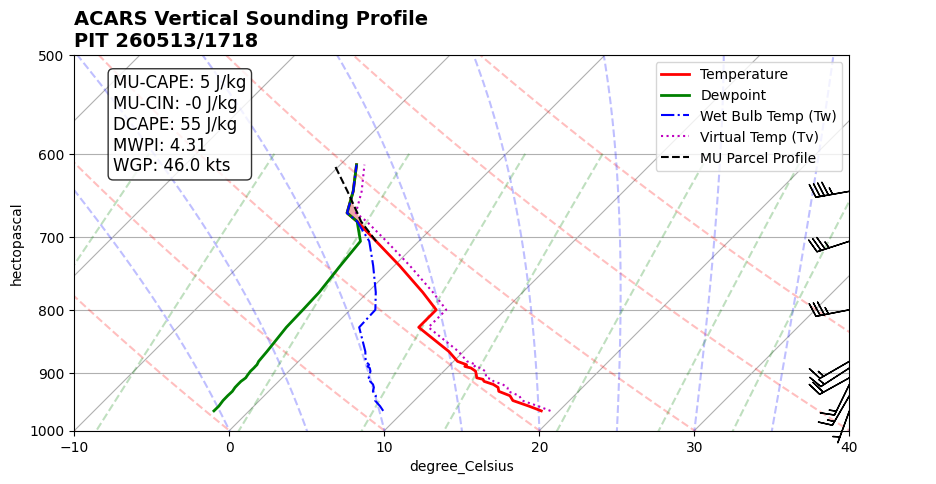

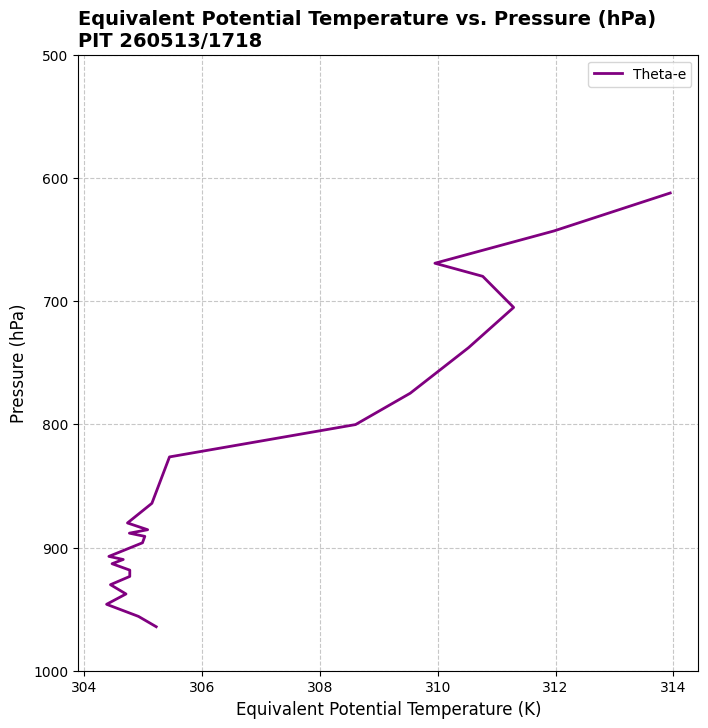

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units

def read_acars_sounding(file_path):
    """
    Reads the ACARS text file in NSHARP format and extracts the meteorological columns.
    """
    # Read the file and find the starting line of the raw data
    with open(file_path, 'r') as f:
        lines = f.readlines()
        
    start_idx = 0
    for i, line in enumerate(lines):
        if '%RAW%' in line:
            start_idx = i + 1
            break
            
    # Load the CSV data into a pandas DataFrame (default comma-separated)
    df = pd.read_csv(file_path, skiprows=start_idx, header=None,
                     names=['pressure', 'height', 'temp', 'dwpt', 'wdir', 'wspd'])
    
    # FORCE numeric conversion to handle any stray text at the end of the file
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna()
    return df

def calculate_dcape(p, T, Td):
    """
    Custom function to calculate DCAPE (Downdraft CAPE).
    """
    try:
        theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)
        
        sfc_p = p[0]
        search_layer_mask = p >= (sfc_p - 400 * units.hPa)
        min_thetae_idx = np.argmin(theta_e[search_layer_mask])
        
        p_origin = p[search_layer_mask][min_thetae_idx]
        T_origin = T[search_layer_mask][min_thetae_idx]
        Td_origin = Td[search_layer_mask][min_thetae_idx]
        
        wb_origin = mpcalc.wet_bulb_temperature(p_origin, T_origin, Td_origin)
        descending_p = p[p >= p_origin]
        
        downdraft_profile = mpcalc.moist_lapse(descending_p, wb_origin, reference_pressure=p_origin)
        env_T = T[p >= p_origin]
        
        delta_p = np.abs(np.diff(descending_p.m)) * units.hPa
        T_diff = (env_T.to('kelvin') - downdraft_profile.to('kelvin'))[:-1]
        Rd = 287.058 * units('J / (kg * K)')
        
        dcape_integral = np.sum(Rd * T_diff * (delta_p / descending_p[:-1]))
        
        return np.max([0, dcape_integral.m]) * units('J/kg')
    except Exception as e:
        print(f"Error calculating DCAPE: {e}")
        return 0 * units('J/kg')

def MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, T_upper, T_lower, TD_upper, TD_lower, CAPE):
    """
    Calculates the Microburst Windspeed Potential Index (MWPI) and Wind Gust Potential (WGP).
    """
    print(f"\n--- Calculating MWPI ({P_level_lower} hPa to {P_level_upper} hPa) ---")
    gamma = (T_lower - T_upper)/(Z_upper - Z_lower)
    print("Gamma = ", gamma)
    DD_upper = T_upper - TD_upper
    print("DD upper = ", DD_upper)
    DD_lower = T_lower - TD_lower
    print("DD lower = ", DD_lower)
    DDD = DD_lower - DD_upper
    print("Delta DD = ", DDD)
    
    # Calculate MWPI
    MWPI_val = (CAPE/1000) + (gamma/5) + (DDD/5)
    
    # Calculate WGP in knots
    WGP = (0.35435365777 * (MWPI_val**2)) + (1.2959855 * MWPI_val) + 33.8176788
    
    print(f"Final MWPI = {MWPI_val:.2f}")
    print(f"Final WGP  = {WGP:.2f} knots\n")
    
    return MWPI_val, WGP

def plot_sounding_data(file_path):
    print(f"Processing ACARS sounding: {file_path}")
    df = read_acars_sounding(file_path)
    
    # Assign MetPy units (Height is in meters, Wind in knots)
    p = df['pressure'].values * units.hPa
    hght = df['height'].values * units.meters
    T = df['temp'].values * units.degC
    Td = df['dwpt'].values * units.degC
    
    # Calculate Wind Components for plotting
    u, v = mpcalc.wind_components(df['wspd'].values * units.knots, df['wdir'].values * units.degrees)
    
    # --- Perform Thermodynamic Calculations ---
    mucape, mucin = mpcalc.most_unstable_cape_cin(p, T, Td)
    mu_p, mu_t, mu_td, mu_idx = mpcalc.most_unstable_parcel(p, T, Td)
    parcel_prof = mpcalc.parcel_profile(p[mu_idx:], mu_t, mu_td).to('degC')
    
    dcape = calculate_dcape(p, T, Td)
    Tw = mpcalc.wet_bulb_temperature(p, T, Td)
    e = mpcalc.saturation_vapor_pressure(Td)
    mixing_ratio = mpcalc.mixing_ratio(e, p)
    Tv = mpcalc.virtual_temperature(T, mixing_ratio)
    theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)

    # --- Interpolate for MWPI Calculation ---
    p_m = p.m
    sort_idx = np.argsort(p_m)
    p_sorted = p_m[sort_idx]
    
    def log_interp_level(target_p, val_arr):
        return np.interp(np.log(target_p), np.log(p_sorted), val_arr[sort_idx])

    # Bound the target levels to the actual profile limits
    P_level_upper = max(700.0, p_sorted[0])
    P_level_lower = min(900.0, p_sorted[-1])
    
    T_upper = log_interp_level(P_level_upper, T.m)
    T_lower = log_interp_level(P_level_lower, T.m)
    TD_upper = log_interp_level(P_level_upper, Td.m)
    TD_lower = log_interp_level(P_level_lower, Td.m)
    
    # Heights converted to km for accurate Gamma calculation
    Z_upper = log_interp_level(P_level_upper, hght.to('km').m)
    Z_lower = log_interp_level(P_level_lower, hght.to('km').m)
    
    mwpi_val, wgp_val = MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, 
                             T_upper, T_lower, TD_upper, TD_lower, mucape.m)

    # ==========================================
    # FIGURE 1: SKEW-T LOG-P DIAGRAM
    # ==========================================
    fig1 = plt.figure(figsize=(10, 10))
    skew = SkewT(fig1, rotation=45)
    
    skew.plot(p, T, 'r', linewidth=2, label='Temperature')
    skew.plot(p, Td, 'g', linewidth=2, label='Dewpoint')
    skew.plot(p, Tw, 'b', linestyle='-.', linewidth=1.5, label='Wet Bulb Temp (Tw)')
    skew.plot(p, Tv, 'm', linestyle=':', linewidth=1.5, label='Virtual Temp (Tv)')
    skew.plot(p[mu_idx:], parcel_prof, 'k', linestyle='--', linewidth=1.5, label='MU Parcel Profile')
    
    skew.shade_cape(p[mu_idx:], T[mu_idx:], parcel_prof)
    skew.shade_cin(p[mu_idx:], T[mu_idx:], parcel_prof, Td[mu_idx:])
    
    # Plot wind barbs (decimate by slicing to avoid overlapping barbs)
    skew.plot_barbs(p[::3], u[::3], v[::3])
    
    skew.plot_dry_adiabats(alpha=0.25)
    skew.plot_moist_adiabats(alpha=0.25)
    skew.plot_mixing_lines(alpha=0.25)
    
    skew.ax.set_ylim(1000, 500)
    skew.ax.set_xlim(-10, 40)
    
    # Updated title to match ACARS observation format
    plt.title('ACARS Vertical Sounding Profile\nPIT 260513/1718', fontsize=14, fontweight='bold', loc='left')
    
    param_text = f"MU-CAPE: {mucape:~P.0f}\nMU-CIN: {mucin:~P.0f}\nDCAPE: {dcape:~P.0f}\nMWPI: {mwpi_val:.2f}\nWGP: {wgp_val:.1f} kts"
    skew.ax.text(0.05, 0.95, param_text, transform=skew.ax.transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    skew.ax.legend(loc='upper right')
    
    output_filename1 = 'ACARS_SkewT_Plot_Advanced_MWPI_1718.png'
    plt.savefig(output_filename1, bbox_inches='tight', dpi=150)
    print(f"Skew-T Plot saved successfully as {output_filename1}")
    
    # ==========================================
    # FIGURE 2: THETA-E VS PRESSURE DIAGRAM
    # ==========================================
    fig2, ax2 = plt.subplots(figsize=(8, 8))
    ax2.plot(theta_e, p, color='purple', linewidth=2, label='Theta-e')
    
    # Invert Y-axis so surface (1000mb) is at the bottom
    ax2.set_ylim(1000, 500)
    ax2.set_yscale('linear') 
    
    ax2.set_xlabel('Equivalent Potential Temperature (K)', fontsize=12)
    ax2.set_ylabel('Pressure (hPa)', fontsize=12)
    ax2.set_title('Equivalent Potential Temperature vs. Pressure (hPa)\nPIT 260513/1718', fontsize=14, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='upper right')
    
    output_filename2 = 'ACARS_ThetaE_Pressure_Plot_1718.png'
    plt.savefig(output_filename2, bbox_inches='tight', dpi=150)
    print(f"Theta-E Profile saved successfully as {output_filename2}")
    
    plt.show()

if __name__ == "__main__":
    file_name = "PIT_1720.txt"
    plot_sounding_data(file_name)

Processing ACARS sounding: PIT_1700.txt

--- Calculating MWPI (900.0 hPa to 700.0 hPa) ---
Gamma =  7.7919466398823625
DD upper =  3.5121145303590513
DD lower =  4.805315991102297
Delta DD =  1.293201460743246
Final MWPI = 1.96
Final WGP  = 37.72 knots

Skew-T Plot saved successfully as ACARS_SkewT_Plot_Advanced_MWPI_1702.png
Theta-E Profile saved successfully as ACARS_ThetaE_Pressure_Plot_1702.png


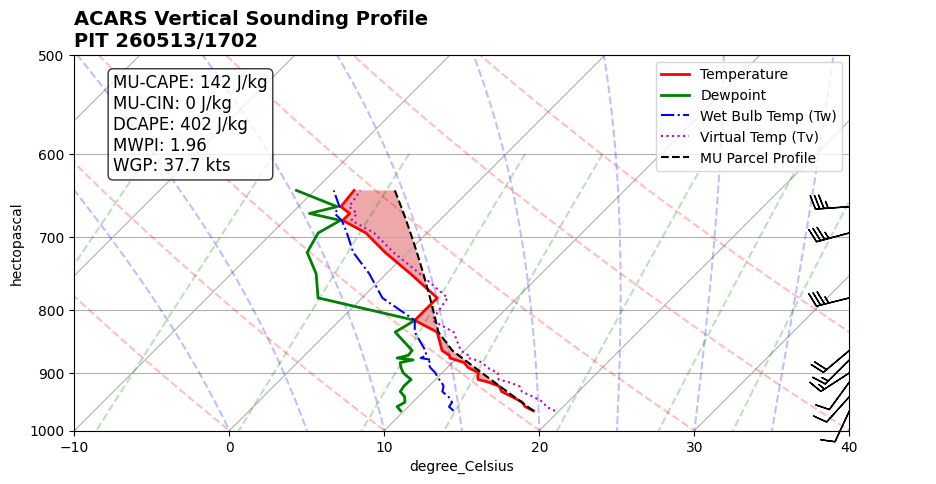

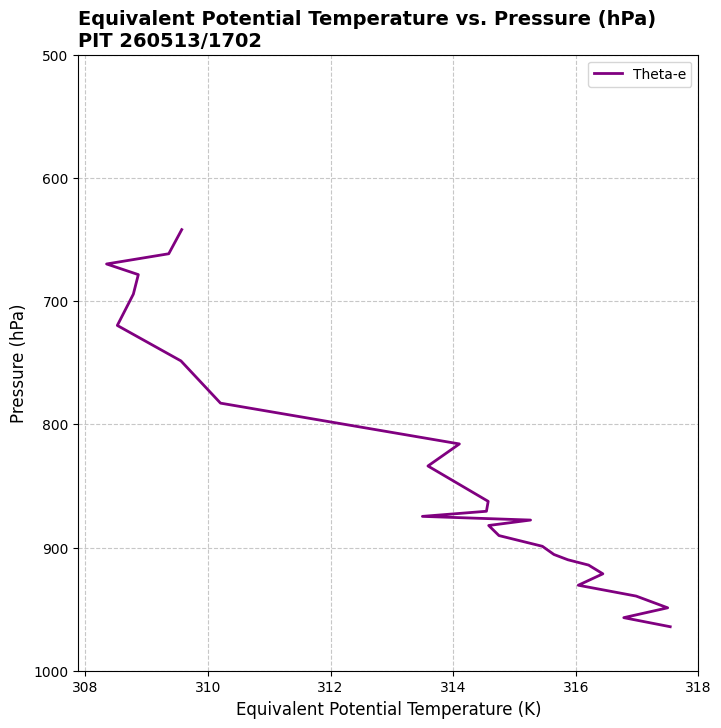

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units

def read_acars_sounding(file_path):
    """
    Reads the ACARS text file in NSHARP format and extracts the meteorological columns.
    """
    # Read the file and find the starting line of the raw data
    with open(file_path, 'r') as f:
        lines = f.readlines()
        
    start_idx = 0
    for i, line in enumerate(lines):
        if '%RAW%' in line:
            start_idx = i + 1
            break
            
    # Load the CSV data into a pandas DataFrame (default comma-separated)
    df = pd.read_csv(file_path, skiprows=start_idx, header=None,
                     names=['pressure', 'height', 'temp', 'dwpt', 'wdir', 'wspd'])
    
    # FORCE numeric conversion to handle any stray text at the end of the file
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna()
    return df

def calculate_dcape(p, T, Td):
    """
    Custom function to calculate DCAPE (Downdraft CAPE).
    """
    try:
        theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)
        
        sfc_p = p[0]
        search_layer_mask = p >= (sfc_p - 400 * units.hPa)
        min_thetae_idx = np.argmin(theta_e[search_layer_mask])
        
        p_origin = p[search_layer_mask][min_thetae_idx]
        T_origin = T[search_layer_mask][min_thetae_idx]
        Td_origin = Td[search_layer_mask][min_thetae_idx]
        
        wb_origin = mpcalc.wet_bulb_temperature(p_origin, T_origin, Td_origin)
        descending_p = p[p >= p_origin]
        
        downdraft_profile = mpcalc.moist_lapse(descending_p, wb_origin, reference_pressure=p_origin)
        env_T = T[p >= p_origin]
        
        delta_p = np.abs(np.diff(descending_p.m)) * units.hPa
        T_diff = (env_T.to('kelvin') - downdraft_profile.to('kelvin'))[:-1]
        Rd = 287.058 * units('J / (kg * K)')
        
        dcape_integral = np.sum(Rd * T_diff * (delta_p / descending_p[:-1]))
        
        return np.max([0, dcape_integral.m]) * units('J/kg')
    except Exception as e:
        print(f"Error calculating DCAPE: {e}")
        return 0 * units('J/kg')

def MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, T_upper, T_lower, TD_upper, TD_lower, CAPE):
    """
    Calculates the Microburst Windspeed Potential Index (MWPI) and Wind Gust Potential (WGP).
    """
    print(f"\n--- Calculating MWPI ({P_level_lower} hPa to {P_level_upper} hPa) ---")
    gamma = (T_lower - T_upper)/(Z_upper - Z_lower)
    print("Gamma = ", gamma)
    DD_upper = T_upper - TD_upper
    print("DD upper = ", DD_upper)
    DD_lower = T_lower - TD_lower
    print("DD lower = ", DD_lower)
    DDD = DD_lower - DD_upper
    print("Delta DD = ", DDD)
    
    # Calculate MWPI
    MWPI_val = (CAPE/1000) + (gamma/5) + (DDD/5)
    
    # Calculate WGP in knots
    WGP = (0.35435365777 * (MWPI_val**2)) + (1.2959855 * MWPI_val) + 33.8176788
    
    print(f"Final MWPI = {MWPI_val:.2f}")
    print(f"Final WGP  = {WGP:.2f} knots\n")
    
    return MWPI_val, WGP

def plot_sounding_data(file_path):
    print(f"Processing ACARS sounding: {file_path}")
    df = read_acars_sounding(file_path)
    
    # Assign MetPy units (Height is in meters, Wind in knots)
    p = df['pressure'].values * units.hPa
    hght = df['height'].values * units.meters
    T = df['temp'].values * units.degC
    Td = df['dwpt'].values * units.degC
    
    # Calculate Wind Components for plotting
    u, v = mpcalc.wind_components(df['wspd'].values * units.knots, df['wdir'].values * units.degrees)
    
    # --- Perform Thermodynamic Calculations ---
    mucape, mucin = mpcalc.most_unstable_cape_cin(p, T, Td)
    mu_p, mu_t, mu_td, mu_idx = mpcalc.most_unstable_parcel(p, T, Td)
    parcel_prof = mpcalc.parcel_profile(p[mu_idx:], mu_t, mu_td).to('degC')
    
    dcape = calculate_dcape(p, T, Td)
    Tw = mpcalc.wet_bulb_temperature(p, T, Td)
    e = mpcalc.saturation_vapor_pressure(Td)
    mixing_ratio = mpcalc.mixing_ratio(e, p)
    Tv = mpcalc.virtual_temperature(T, mixing_ratio)
    theta_e = mpcalc.equivalent_potential_temperature(p, T, Td)

    # --- Interpolate for MWPI Calculation ---
    p_m = p.m
    sort_idx = np.argsort(p_m)
    p_sorted = p_m[sort_idx]
    
    def log_interp_level(target_p, val_arr):
        return np.interp(np.log(target_p), np.log(p_sorted), val_arr[sort_idx])

    # Bound the target levels to the actual profile limits
    P_level_upper = max(700.0, p_sorted[0])
    P_level_lower = min(900.0, p_sorted[-1])
    
    T_upper = log_interp_level(P_level_upper, T.m)
    T_lower = log_interp_level(P_level_lower, T.m)
    TD_upper = log_interp_level(P_level_upper, Td.m)
    TD_lower = log_interp_level(P_level_lower, Td.m)
    
    # Heights converted to km for accurate Gamma calculation
    Z_upper = log_interp_level(P_level_upper, hght.to('km').m)
    Z_lower = log_interp_level(P_level_lower, hght.to('km').m)
    
    mwpi_val, wgp_val = MWPI(P_level_upper, P_level_lower, Z_upper, Z_lower, 
                             T_upper, T_lower, TD_upper, TD_lower, mucape.m)

    # ==========================================
    # FIGURE 1: SKEW-T LOG-P DIAGRAM
    # ==========================================
    fig1 = plt.figure(figsize=(10, 10))
    skew = SkewT(fig1, rotation=45)
    
    skew.plot(p, T, 'r', linewidth=2, label='Temperature')
    skew.plot(p, Td, 'g', linewidth=2, label='Dewpoint')
    skew.plot(p, Tw, 'b', linestyle='-.', linewidth=1.5, label='Wet Bulb Temp (Tw)')
    skew.plot(p, Tv, 'm', linestyle=':', linewidth=1.5, label='Virtual Temp (Tv)')
    skew.plot(p[mu_idx:], parcel_prof, 'k', linestyle='--', linewidth=1.5, label='MU Parcel Profile')
    
    skew.shade_cape(p[mu_idx:], T[mu_idx:], parcel_prof)
    skew.shade_cin(p[mu_idx:], T[mu_idx:], parcel_prof, Td[mu_idx:])
    
    # Plot wind barbs (decimate by slicing to avoid overlapping barbs)
    skew.plot_barbs(p[::3], u[::3], v[::3])
    
    skew.plot_dry_adiabats(alpha=0.25)
    skew.plot_moist_adiabats(alpha=0.25)
    skew.plot_mixing_lines(alpha=0.25)
    
    skew.ax.set_ylim(1000, 500)
    skew.ax.set_xlim(-10, 40)
    
    # Updated title to match ACARS observation format
    plt.title('ACARS Vertical Sounding Profile\nPIT 260513/1702', fontsize=14, fontweight='bold', loc='left')
    
    param_text = f"MU-CAPE: {mucape:~P.0f}\nMU-CIN: {mucin:~P.0f}\nDCAPE: {dcape:~P.0f}\nMWPI: {mwpi_val:.2f}\nWGP: {wgp_val:.1f} kts"
    skew.ax.text(0.05, 0.95, param_text, transform=skew.ax.transAxes, fontsize=12,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    skew.ax.legend(loc='upper right')
    
    output_filename1 = 'ACARS_SkewT_Plot_Advanced_MWPI_1702.png'
    plt.savefig(output_filename1, bbox_inches='tight', dpi=150)
    print(f"Skew-T Plot saved successfully as {output_filename1}")
    
    # ==========================================
    # FIGURE 2: THETA-E VS PRESSURE DIAGRAM
    # ==========================================
    fig2, ax2 = plt.subplots(figsize=(8, 8))
    ax2.plot(theta_e, p, color='purple', linewidth=2, label='Theta-e')
    
    # Invert Y-axis so surface (1000mb) is at the bottom
    ax2.set_ylim(1000, 500)
    ax2.set_yscale('linear') 
    
    ax2.set_xlabel('Equivalent Potential Temperature (K)', fontsize=12)
    ax2.set_ylabel('Pressure (hPa)', fontsize=12)
    ax2.set_title('Equivalent Potential Temperature vs. Pressure (hPa)\nPIT 260513/1702', fontsize=14, fontweight='bold', loc='left')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend(loc='upper right')
    
    output_filename2 = 'ACARS_ThetaE_Pressure_Plot_1702.png'
    plt.savefig(output_filename2, bbox_inches='tight', dpi=150)
    print(f"Theta-E Profile saved successfully as {output_filename2}")
    
    plt.show()

if __name__ == "__main__":
    file_name = "PIT_1700.txt"
    plot_sounding_data(file_name)